In [1]:
import pandas as pd 
import torch
import numpy as np
import random
import os
from matplotlib import pyplot as plt

def set_seed(seed: int = 42) -> None:
    """Sets the random seed for reproducibility across PyTorch, NumPy, and Python's random module."""
    os.environ['PYTHONHASHSEED'] = str(seed)  # For Python's hash seed
    torch.manual_seed(seed)  # For PyTorch's CPU and CUDA RNGs
    torch.cuda.manual_seed(seed)  # For CUDA devices specifically
    torch.cuda.manual_seed_all(seed) # For all CUDA devices if multiple are used
    np.random.seed(seed)  # For NumPy's random number generator
    random.seed(seed)  # For Python's built-in random module

    # For deterministic algorithms in PyTorch (optional, but recommended for full reproducibility)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Example usage:
set_seed(123)

In [2]:
import sys
import os

# Add project root (parent of "src") to Python path
sys.path.append(os.path.abspath(".."))

from src.data_loader import load_OhioT1DM_patient_split

Ohio_PATH = "..\data\\raw\\" 
data = load_OhioT1DM_patient_split(path=Ohio_PATH, look_back=128)

In [3]:
X_train, X_val, X_test, y_reg_train, y_reg_val, y_reg_test, y_clf_train, y_clf_val, y_clf_test = data

In [4]:
y_clf_test.shape

(10329,)

In [5]:
import glob 
import re

generated_PATH = "..\data\\generated\\synth_**.pt"

generated_paths  = glob.glob(generated_PATH) 

pattern = r"synth_(\w+)\.pt"  # capture word characters between 'synth_' and '.pt'

generated_data = {}

for path in generated_paths: 
    
    data = torch.load(path, weights_only=False)
    file_name = path.split("\\")[-1]
    match = re.search(pattern, file_name)
    generator = match.group(1)
    data = data.clip(40, 400)
    generated_data[generator] = np.array(data.detach().cpu()).reshape(-1, 128)
        
    print(f"synth data generated by {generator} loaded: {file_name} .")



synth data generated by ddpm loaded: synth_ddpm.pt .
synth data generated by gan loaded: synth_gan.pt .
synth data generated by nf loaded: synth_nf.pt .
synth data generated by vae loaded: synth_vae.pt .


In [6]:
MIN = 40
MAX = 400 

function_reverse = lambda t: (t / 2 + 0.5) * (MAX - MIN) + MIN 

In [7]:
Evaluation_results = {} 

Evaluation_results ["StatisticalFidelity"] = {}

In [8]:
X = np.concatenate([X_train, X_val])

## Statistical Fidelity

Higher-Order Statistics: Compare overall behavior

In [9]:
from scipy.stats import skew, kurtosis

x = X_test

Evaluation_results ["StatisticalFidelity"]["HighOredeStats"] = {"Criterions" : ["mean", "std", "skew", "kurtosis"]}
summary = lambda x: [np.mean(x), np.std(x), skew(x), kurtosis(x)]
Evaluation_results ["StatisticalFidelity"]["HighOredeStats"]["OhioT1dm"] = summary(x.ravel())

for model, data in generated_data.items(): 
    
    Evaluation_results ["StatisticalFidelity"]["HighOredeStats"][model] = summary(data[:len(x)].ravel())
    print(f"\n{model}")
    print("Real:", summary(x.ravel()))
    print("Synth:", summary(data.ravel()))



ddpm
Real: [158.95662, 58.601616, 0.7028337846483786, 0.5886059916113142]
Synth: [165.0576, 56.6758, 0.5060255052036503, 0.013170808577879445]

gan
Real: [158.95662, 58.601616, 0.7028337846483786, 0.5886059916113142]
Synth: [158.6121, 59.29298, 0.6306257073432653, 0.1589100699767001]

nf
Real: [158.95662, 58.601616, 0.7028337846483786, 0.5886059916113142]
Synth: [158.95094, 61.961403, 0.7706537255702506, 0.8529364953808298]

vae
Real: [158.95662, 58.601616, 0.7028337846483786, 0.5886059916113142]
Synth: [99.526886, 8.013357, -0.6029870280890338, 2.674049974459714]


In [10]:
x.shape


(10329, 128)

Marginal Distribution Comparison: Compare glucose range/shape

In [11]:
from scipy.stats import ks_2samp
import numpy as np

Evaluation_results ["StatisticalFidelity"]["KS_Test"] = {"Criterions" : ["ks_stat", "p_val"]}


for model, data in generated_data.items(): 
    
    ks_stat, p_val = ks_2samp(x.ravel(), data[:len(x)].ravel())
    Evaluation_results ["StatisticalFidelity"]["KS_Test"][model] = [ks_stat, p_val]
    print(f"KS statistic {model} = {ks_stat:.4f}, p-value = {p_val:.4f}")

KS statistic ddpm = 0.0673, p-value = 0.0000
KS statistic gan = 0.0216, p-value = 0.0000
KS statistic nf = 0.0213, p-value = 0.0000
KS statistic vae = 0.7326, p-value = 0.0000


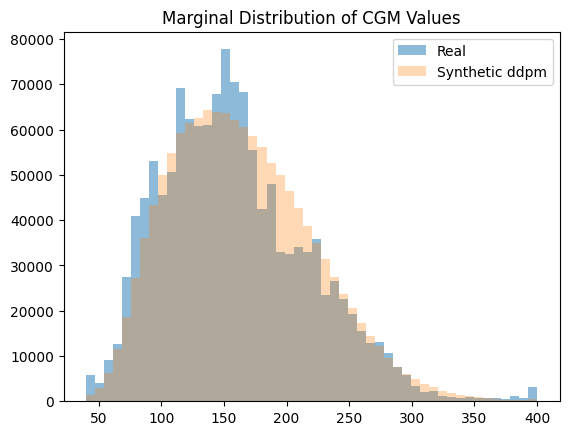

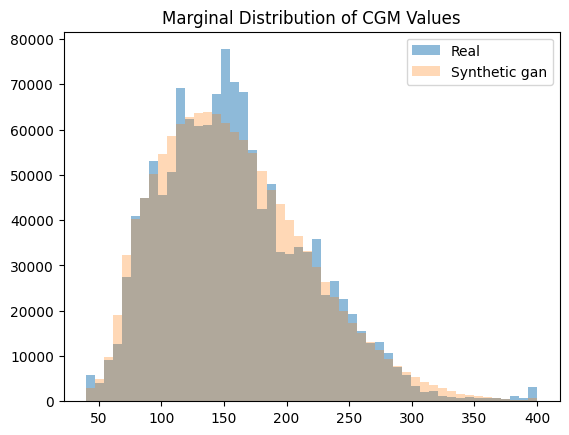

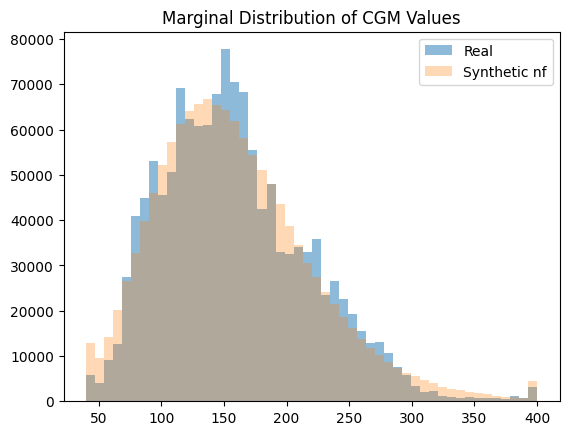

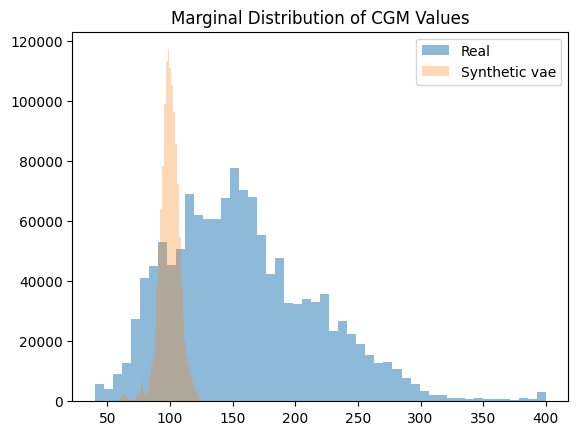

In [12]:
import matplotlib.pyplot as plt


for model, data in generated_data.items(): 
    plt.hist(x.ravel(), bins=50, alpha=0.5, label="Real")
    plt.hist(data[:len(x)].ravel(), bins=50, alpha=0.3, label=f"Synthetic {model}")
    plt.legend(); plt.title("Marginal Distribution of CGM Values")
    plt.show()



Generating combined distribution comparison...


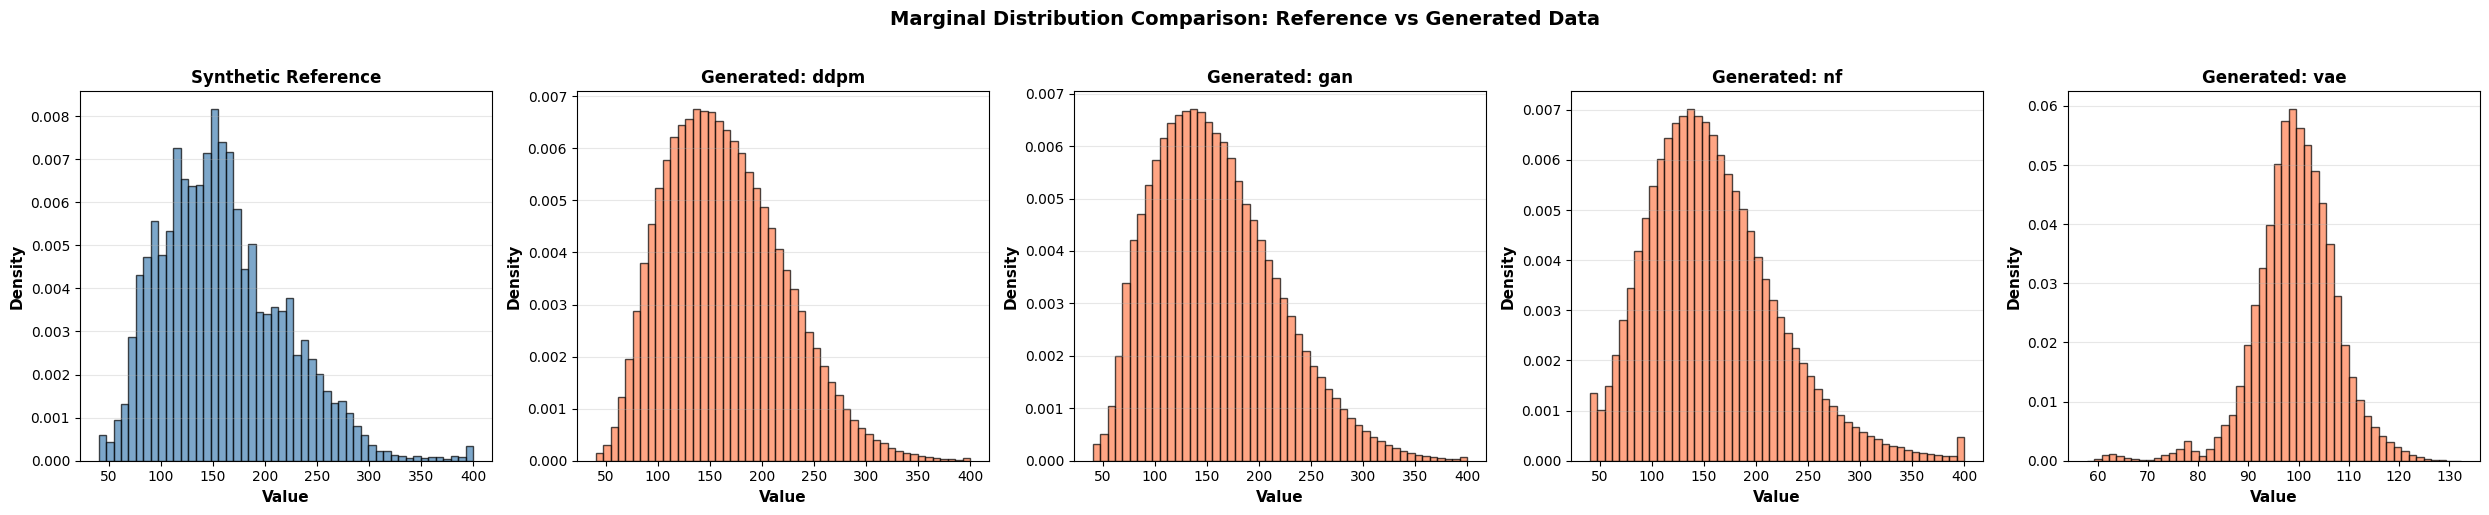

In [13]:
# Option 2: Combined comparison (all models in one plot) - RECOMMENDED
print("\nGenerating combined distribution comparison...")
fig, axes = plt.subplots(1, len(generated_data) + 1, figsize=(5 * (len(generated_data) + 1), 5))

# Handle case with single model
if len(generated_data) == 1:
    axes = [axes]

# Plot reference distribution in first subplot
axes[0].hist(x.ravel(), bins=50, alpha=0.7, color='steelblue', edgecolor='black', density=True)
axes[0].set_xlabel('Value', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Density', fontsize=11, fontweight='bold')
axes[0].set_title('Synthetic Reference', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Plot each model's distribution
for idx, (model, data) in enumerate(generated_data.items(), start=1):
    axes[idx].hist(data[:len(x)].ravel(), bins=50, alpha=0.7, 
                   color='coral', edgecolor='black', density=True)
    axes[idx].set_xlabel('Value', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Density', fontsize=11, fontweight='bold')
    axes[idx].set_title(f'Generated: {model}', fontsize=12, fontweight='bold')
    axes[idx].grid(axis='y', alpha=0.3)

plt.suptitle('Marginal Distribution Comparison: Reference vs Generated Data', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


Temporal Dependence (Dynamics): Check lag dependencies

ACF difference ddpm: 0.1825
ACF difference gan: 0.2033
ACF difference nf: 0.1417
ACF difference vae: 2.1849


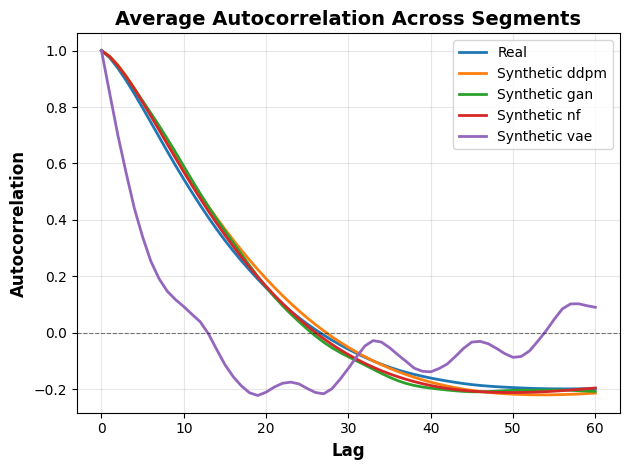

In [14]:
from statsmodels.tsa.stattools import acf

Evaluation_results ["StatisticalFidelity"]["TemporalDependence"] = {"Criterions" : ["acf_diff"]}

def mean_acf(X, nlags=60):
    acfs = []
    for row in X:
        acfs.append(acf(row, nlags=nlags))
    return np.mean(acfs, axis=0)

acf_real = mean_acf(x)
plt.plot(acf_real, label="Real", linewidth=2)

for model, data in generated_data.items(): 
    acf_synth = mean_acf(data[:len(x)])
    acf_diff = np.linalg.norm(acf_real - acf_synth)
    Evaluation_results ["StatisticalFidelity"]["TemporalDependence"][model] = [acf_diff]
    print(f"ACF difference {model}: {acf_diff:.4f}")
    plt.plot(acf_synth, label=f"Synthetic {model}", linewidth=2)

plt.xlabel("Lag", fontsize=12, fontweight='bold')
plt.ylabel("Autocorrelation", fontsize=12, fontweight='bold')
plt.title("Average Autocorrelation Across Segments", fontsize=14, fontweight='bold')
plt.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


Spectral Properties (Frequency Domain): Compare periodicity

PSD difference ddpm: 3800.7881
Log PSD difference ddpm: 7.3045
PSD difference gan: 21557.3594
Log PSD difference gan: 2.4501
PSD difference nf: 31914.5176
Log PSD difference nf: 1.1677
PSD difference vae: 115055.8906
Log PSD difference vae: 13.2548


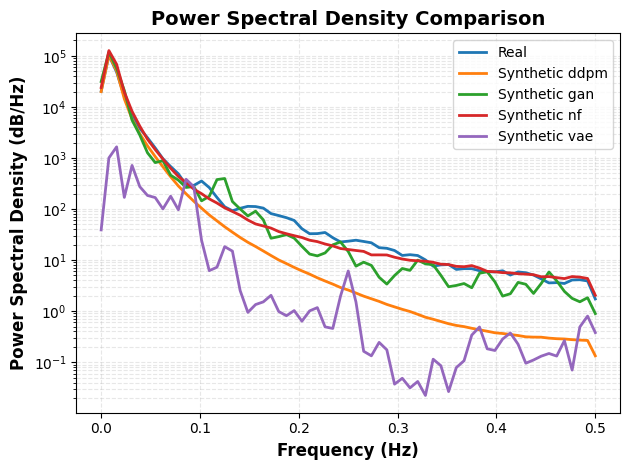

In [15]:
from scipy.signal import welch

Evaluation_results ["StatisticalFidelity"]["SpectralProperties"] = {"Criterions" : ["PSD_diff", "Log_PSD_diff"]}

f_real, Pxx_real = welch(x, nperseg=128)
plt.semilogy(f_real, Pxx_real.mean(axis=0), label='Real', linewidth=2) 
psd_real = Pxx_real.mean(axis=0).ravel()

for model, data in generated_data.items(): 
    f_synth, Pxx_synth = welch(data[:len(x)], nperseg=128)
    psd_synth = Pxx_synth.mean(axis=0).ravel()
    psd_diff = np.linalg.norm(psd_real - psd_synth) 
    psd_diff_log = np.linalg.norm(np.log10(psd_real + 1e-10) - np.log10(psd_synth + 1e-10))
    Evaluation_results ["StatisticalFidelity"]["SpectralProperties"][model] = [psd_diff, psd_diff_log]
    print(f"PSD difference {model}: {psd_diff:.4f}")
    print(f"Log PSD difference {model}: {psd_diff_log:.4f}")
    plt.semilogy(f_synth, psd_synth, label=f'Synthetic {model}', linewidth=2)

plt.xlabel("Frequency (Hz)", fontsize=12, fontweight='bold')
plt.ylabel("Power Spectral Density (dB/Hz)", fontsize=12, fontweight='bold')
plt.title("Power Spectral Density Comparison", fontsize=14, fontweight='bold')
plt.grid(which='both', alpha=0.3, linestyle='--')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()


In [16]:
Evaluation_results

{'StatisticalFidelity': {'HighOredeStats': {'Criterions': ['mean',
    'std',
    'skew',
    'kurtosis'],
   'OhioT1dm': [158.95662, 58.601616, 0.7028337846483786, 0.5886059916113142],
   'ddpm': [164.75896, 56.807552, 0.5193680682848147, 0.023576038710228175],
   'gan': [158.54024, 59.212837, 0.6344672316651678, 0.1822407786845459],
   'nf': [158.72916, 62.07762, 0.7851328191305816, 0.8673010098646188],
   'vae': [99.51608, 8.019219, -0.6081292248776091, 2.676438882339065]},
  'KS_Test': {'Criterions': ['ks_stat', 'p_val'],
   'ddpm': [0.06728325588149864, 0.0],
   'gan': [0.021565495207667706, 1.6993277051335898e-267],
   'nf': [0.021284883580211057, 1.3675954995435765e-260],
   'vae': [0.7326398973763191, 0.0]},
  'TemporalDependence': {'Criterions': ['acf_diff'],
   'ddpm': [0.18252376722574876],
   'gan': [0.20334310500446773],
   'nf': [0.14172735293055064],
   'vae': [2.1849320570343953]},
  'SpectralProperties': {'Criterions': ['PSD_diff', 'Log_PSD_diff'],
   'ddpm': [3800.788

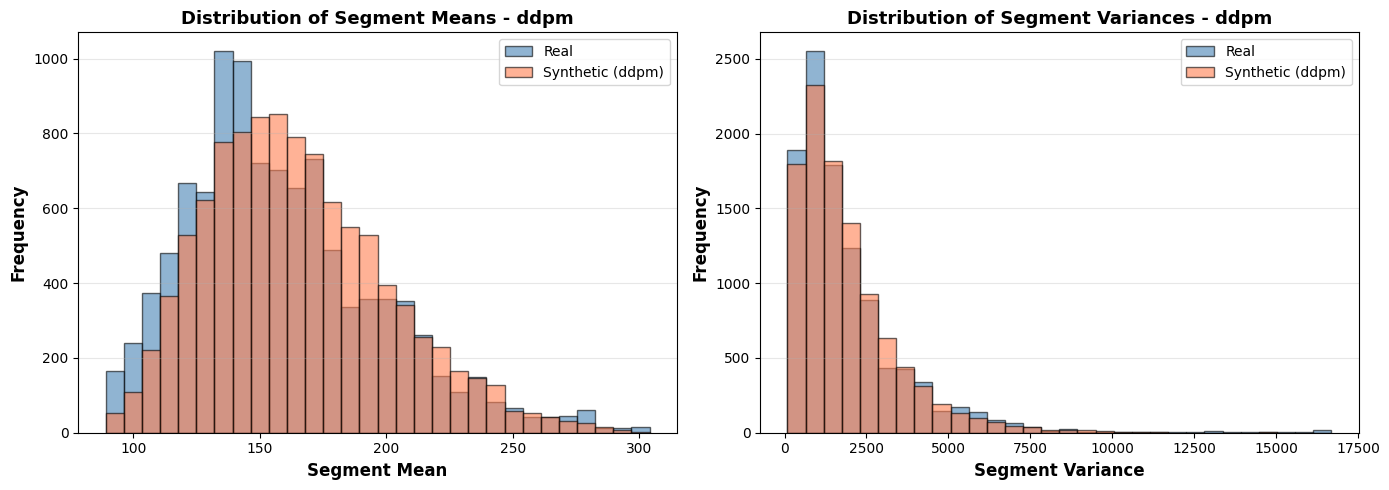


ddpm:
  Mean - KS=0.1050, p-value=0.0000
  Var  - KS=0.0345, p-value=0.0000
  ✗ Mean distributions differ significantly
  ✗ Variance distributions differ significantly


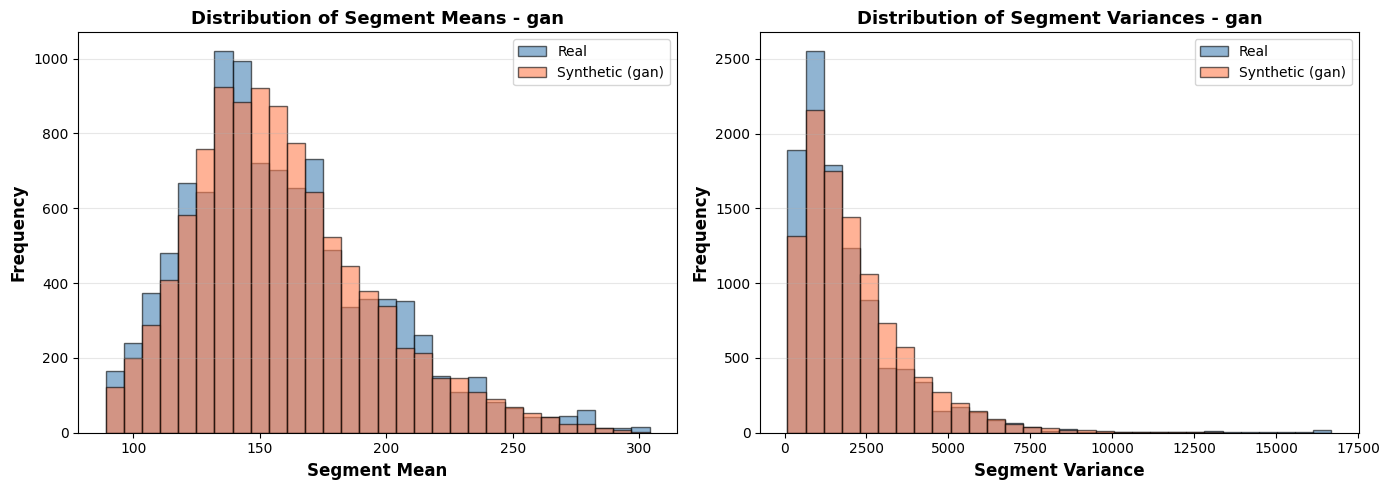


gan:
  Mean - KS=0.0331, p-value=0.0000
  Var  - KS=0.1020, p-value=0.0000
  ✗ Mean distributions differ significantly
  ✗ Variance distributions differ significantly


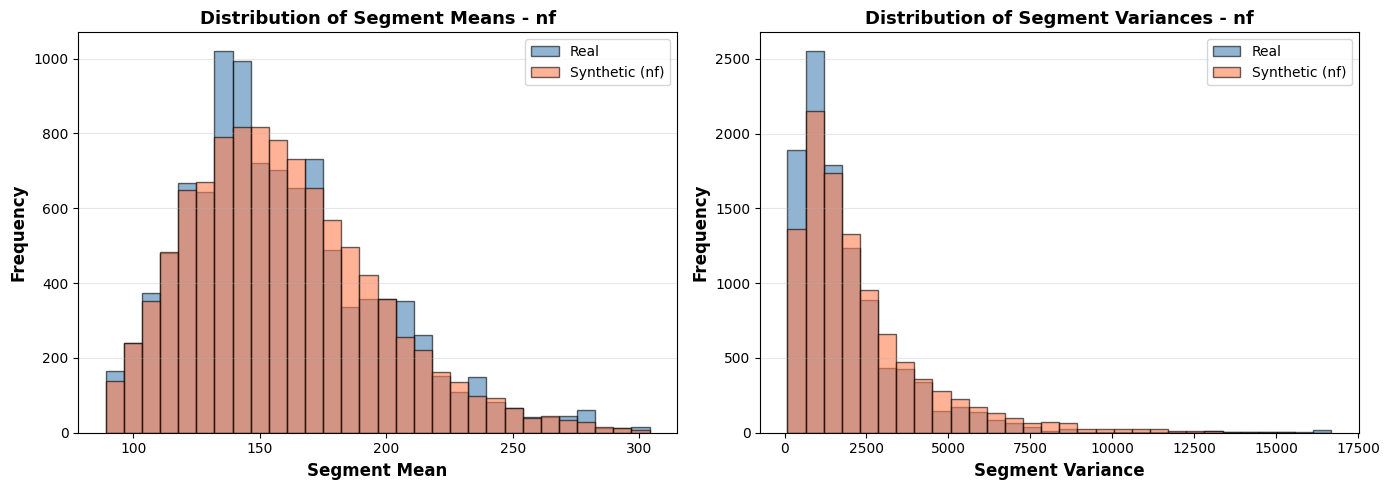


nf:
  Mean - KS=0.0312, p-value=0.0001
  Var  - KS=0.0965, p-value=0.0000
  ✗ Mean distributions differ significantly
  ✗ Variance distributions differ significantly


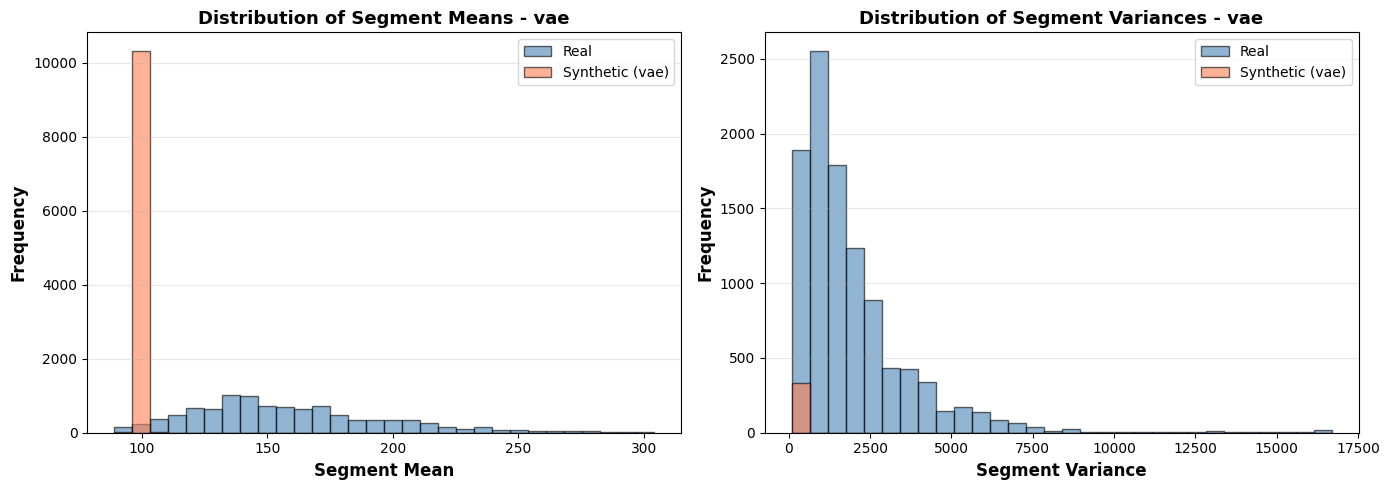


vae:
  Mean - KS=0.9607, p-value=0.0000
  Var  - KS=0.9960, p-value=0.0000
  ✗ Mean distributions differ significantly
  ✗ Variance distributions differ significantly


In [17]:
# Compute real data statistics once (outside loop)
mean_real = x.mean(axis=1)
var_real = x.var(axis=1)

# Initialize results storage
Evaluation_results["StatisticalFidelity"]["MomentMatching"] = {
    "Criterions": ["ks_mean", "p_mean", "ks_var", "p_var"]
}

for model, data in generated_data.items():   
    mean_synth = data[:len(x)].mean(axis=1)
    var_synth = data[:len(x)].var(axis=1)

    # Create figure with two subplots
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Use adaptive binning based on data range
    bins_mean = np.linspace(mean_real.min(), mean_real.max(), 31)
    bins_var = np.linspace(var_real.min(), var_real.max(), 31)
    
    # Plot 1: Mean distribution
    axes[0].hist(mean_real, bins=bins_mean, alpha=0.6, label="Real", color='steelblue', edgecolor='black')
    axes[0].hist(mean_synth, bins=bins_mean, alpha=0.6, label=f"Synthetic ({model})", color='coral', edgecolor='black')
    axes[0].set_xlabel("Segment Mean", fontsize=12, fontweight='bold')
    axes[0].set_ylabel("Frequency", fontsize=12, fontweight='bold')
    axes[0].set_title(f"Distribution of Segment Means - {model}", fontsize=13, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(axis='y', alpha=0.3)
    
    # Plot 2: Variance distribution
    axes[1].hist(var_real, bins=bins_var, alpha=0.6, label="Real", color='steelblue', edgecolor='black')
    axes[1].hist(var_synth, bins=bins_var, alpha=0.6, label=f"Synthetic ({model})", color='coral', edgecolor='black')
    axes[1].set_xlabel("Segment Variance", fontsize=12, fontweight='bold')
    axes[1].set_ylabel("Frequency", fontsize=12, fontweight='bold')
    axes[1].set_title(f"Distribution of Segment Variances - {model}", fontsize=13, fontweight='bold')
    axes[1].legend(fontsize=10)
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

    # Perform KS tests
    ks_mean, p_mean = ks_2samp(mean_real, mean_synth)
    ks_var, p_var = ks_2samp(var_real, var_synth)
    
    # Store results
    Evaluation_results["StatisticalFidelity"]["MomentMatching"][model] = [
        ks_mean, p_mean, ks_var, p_var
    ]
    
    # Print results with model name
    print(f"\n{model}:")
    print(f"  Mean - KS={ks_mean:.4f}, p-value={p_mean:.4f}")
    print(f"  Var  - KS={ks_var:.4f}, p-value={p_var:.4f}")
    
    # Interpretation
    if p_mean > 0.05:
        print(f"  ✓ Mean distributions are statistically similar")
    else:
        print(f"  ✗ Mean distributions differ significantly")
    
    if p_var > 0.05:
        print(f"  ✓ Variance distributions are statistically similar")
    else:
        print(f"  ✗ Variance distributions differ significantly")


## Diversity

coverage ratio using FrechetDistance (FID) and UMAP (GANsTrained by a Two Time-Scale Update Rule
 Converge to a Local Nash Equilibrium, Improved Precision and Recall Metric for Assessing Generative Models)

In [ ]:
import numpy as np
from sklearn.decomposition import PCA
import umap
import matplotlib.pyplot as plt
from scipy.linalg import sqrtm
from scipy.spatial.distance import cdist 
from sklearn.manifold import trustworthiness

Evaluation_results ["Diversity"] = {"Criterions" : ["FID", "Precision", "Recall"]}

def frechet_distance(X, Y):
    mu_x, mu_y = X.mean(0), Y.mean(0)
    cov_x, cov_y = np.cov(X, rowvar=False), np.cov(Y, rowvar=False)
    covmean = sqrtm(cov_x.dot(cov_y)).real
    return np.sum((mu_x - mu_y)**2) + np.trace(cov_x + cov_y - 2*covmean)

# Step 1: PCA (retain most variance)
pca = PCA(n_components=0.95)
pca.fit(X_train)
real_pca = pca.transform(x)
umap_model = umap.UMAP(n_neighbors=30, learning_rate=0.1, min_dist=0.1, metric='euclidean', random_state=42, n_epochs=1500, init="random")
umap_model.fit(X_train)
real_umap = umap_model.transform(real_pca) 
df = pd.DataFrame(real_umap)
mask = df.isna().values
mask = np.any(mask, axis = 1)
real_umap = df.dropna().values

# Step 3: Verify stability
trust_score = trustworthiness(real_pca[~mask], real_umap, n_neighbors=12)
print(f"Embedding trustworthiness: {trust_score:.3f}")
if trust_score < 0.8:
    print("⚠️ Warning: UMAP may be distorting structure. Consider tuning parameters.")

c:\Users\MEROUANE\miniconda3\envs\data\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\MEROUANE\miniconda3\envs\data\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Embedding trustworthiness: 0.769
⚠️ Warning: UMAP may be distorting structure. Consider tuning parameters.


FID-like diversity score ddpm: 5722.403
Prec-Recl in Umap Space ddpm: 0.680, 0.853


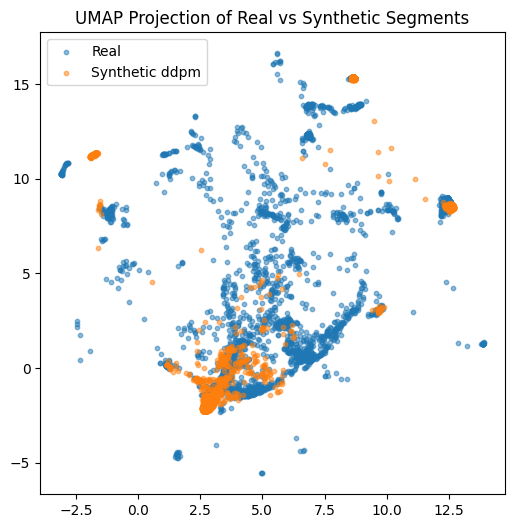

FID-like diversity score gan: 18139.433
Prec-Recl in Umap Space gan: 0.722, 0.880


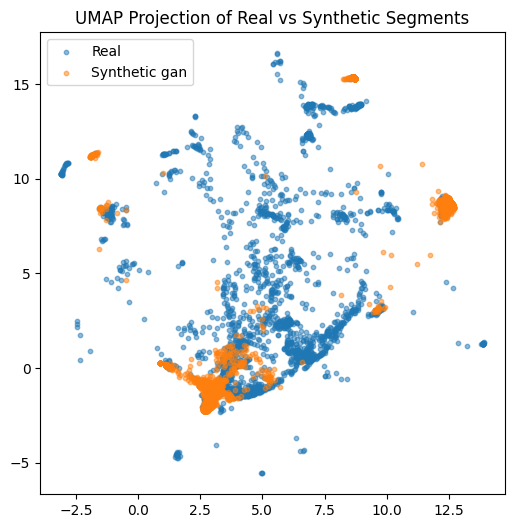

FID-like diversity score nf: 4710.322
Prec-Recl in Umap Space nf: 0.659, 0.891


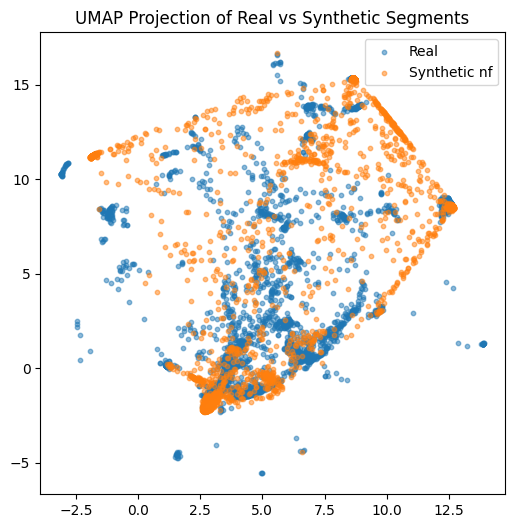

FID-like diversity score vae: 840669.593
Prec-Recl in Umap Space vae: 0.541, 0.516


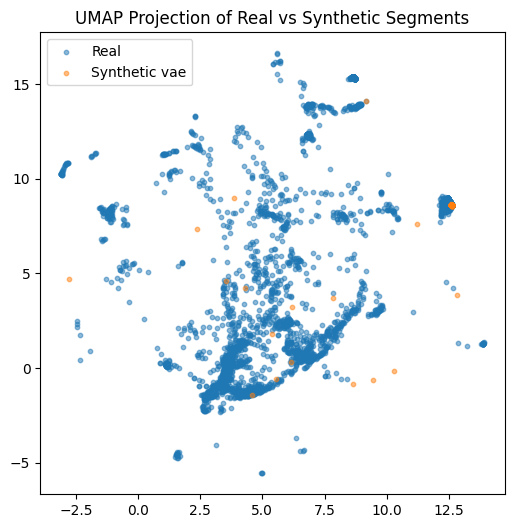

In [19]:
def coverage_ratio_func(X_real, X_synth, threshold=0.1):
    """
    Calculate what fraction of real samples are covered by synthetic samples.
    
    Args:
        X_real: Real data points (N x D)
        X_synth: Synthetic data points (M x D)
        threshold: Distance threshold for "coverage"
    
    Returns:
        Fraction of real samples with at least one synthetic neighbor within threshold
    """
    coverage = np.mean([
        np.min(np.linalg.norm(X_synth - r[None, :], axis=-1)) < threshold
        for r in X_real
    ])
    return coverage

def precision_recall_kynkaanniemi(X_real, X_synth, k=3):
    """
    Standard Precision-Recall for distributions.
    
    Most cited implementation: Kynkäänniemi et al., NeurIPS 2019
    "Improved Precision and Recall Metric for Assessing Generative Models"
    
    Uses k-th NN distance as LOCAL threshold (adapts to density)
    """
    from sklearn.neighbors import NearestNeighbors
    
    # Build k-NN models
    # k+1 because first neighbor is the point itself
    nbrs_real = NearestNeighbors(n_neighbors=k+1, metric='euclidean').fit(X_real)
    nbrs_synth = NearestNeighbors(n_neighbors=k+1, metric='euclidean').fit(X_synth)
    
    # === STEP 1: Define "manifolds" using k-th NN distance ===
    # For each real point, find its k-th nearest neighbor
    real_distances, _ = nbrs_real.kneighbors(X_real)
    real_radii = real_distances[:, k]  # k-th column = k-th NN distance
    
    # For each synth point, find its k-th nearest neighbor
    synth_distances, _ = nbrs_synth.kneighbors(X_synth)
    synth_radii = synth_distances[:, k]
    
    # === STEP 2: Precision ===
    # For each synthetic sample, find nearest real sample
    synth_to_real_dist, synth_to_real_idx = nbrs_real.kneighbors(X_synth, n_neighbors=1)
    synth_to_real_dist = synth_to_real_dist.flatten()
    synth_to_real_idx = synth_to_real_idx.flatten()
    
    # A synth sample has good "precision" if it's within the real manifold
    # i.e., distance to nearest real < that real point's k-th NN radius
    precision = np.mean(synth_to_real_dist < real_radii[synth_to_real_idx])
    
    # === STEP 3: Recall (Coverage) ===
    # For each real sample, find nearest synthetic sample
    real_to_synth_dist, real_to_synth_idx = nbrs_synth.kneighbors(X_real, n_neighbors=1)
    real_to_synth_dist = real_to_synth_dist.flatten()
    real_to_synth_idx = real_to_synth_idx.flatten()
    
    # A real sample is "covered" if it's within the synthetic manifold
    # i.e., distance to nearest synth < that synth point's k-th NN radius
    recall = np.mean(real_to_synth_dist < synth_radii[real_to_synth_idx])
    
    return precision, recall


for model, data in generated_data.items(): 
    # Visualization
    plt.figure(figsize=(6,6))
    plt.scatter(real_umap[:,0], real_umap[:,1], s=10, alpha=0.5, label="Real")
    synth_pca = pca.transform(data[:len(x)])
    # Step 2: UMAP (for nonlinear manifold)
    synth_umap = umap_model.transform(synth_pca) 
    df_synth = pd.DataFrame(synth_umap)
    synth_umap = df_synth.dropna().values
    
    fid_score = frechet_distance(real_pca, synth_pca)
    
    precision, recall = precision_recall_kynkaanniemi(real_umap, synth_umap, k=3)
    
    #coverage_ratio = coverage_ratio_func(real_umap, synth_umap, threshold=0.1)
    Evaluation_results ["Diversity"][model] = [fid_score, precision, recall]
    print(f"FID-like diversity score {model}: {fid_score:.3f}")
    print(f"Prec-Recl in Umap Space {model}: {precision:.3f}, {recall:.3f}")
    
    plt.scatter(synth_umap[:,0], synth_umap[:,1], s=10, alpha=0.5, label=f"Synthetic {model}")
    
    plt.legend(); plt.title("UMAP Projection of Real vs Synthetic Segments")
    plt.show()


## Privacy

Nearest-Neighbor Similarity Test

In [20]:
Evaluation_results ["Privacy"] = {}

c:\Users\MEROUANE\miniconda3\envs\data\lib\site-packages\sklearn\metrics\pairwise.py:611: RuntimeWarning: overflow encountered in scalar multiply
  + (x_density * n_samples_X * y_density * n_samples_Y)


Avg nearest neighbor distance RR: 58.377 ± 20.612


c:\Users\MEROUANE\miniconda3\envs\data\lib\site-packages\sklearn\metrics\pairwise.py:611: RuntimeWarning: overflow encountered in scalar multiply
  + (x_density * n_samples_X * y_density * n_samples_Y)


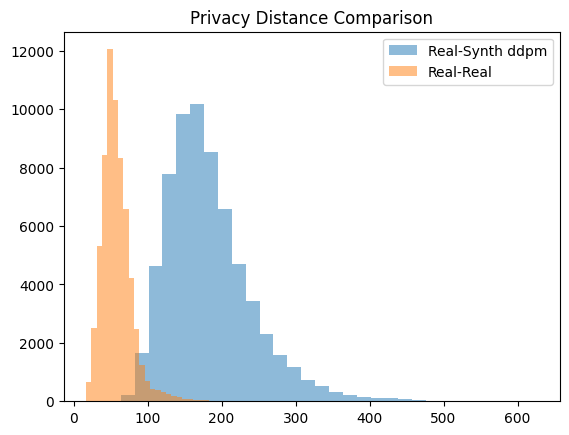

Avg nearest neighbor distance ddpm: 183.082 ± 58.253
✅ Synthetic samples are sufficiently distinct


c:\Users\MEROUANE\miniconda3\envs\data\lib\site-packages\sklearn\metrics\pairwise.py:611: RuntimeWarning: overflow encountered in scalar multiply
  + (x_density * n_samples_X * y_density * n_samples_Y)


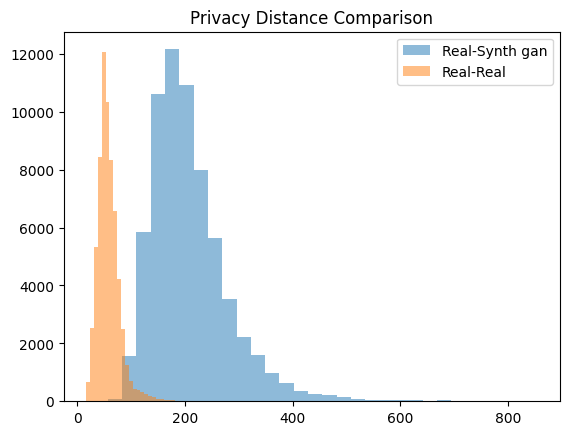

Avg nearest neighbor distance gan: 208.261 ± 72.194
✅ Synthetic samples are sufficiently distinct


c:\Users\MEROUANE\miniconda3\envs\data\lib\site-packages\sklearn\metrics\pairwise.py:611: RuntimeWarning: overflow encountered in scalar multiply
  + (x_density * n_samples_X * y_density * n_samples_Y)


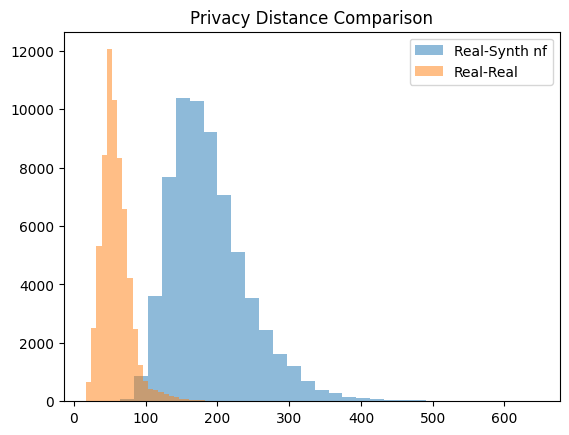

Avg nearest neighbor distance nf: 189.349 ± 56.523
✅ Synthetic samples are sufficiently distinct


c:\Users\MEROUANE\miniconda3\envs\data\lib\site-packages\sklearn\metrics\pairwise.py:611: RuntimeWarning: overflow encountered in scalar multiply
  + (x_density * n_samples_X * y_density * n_samples_Y)


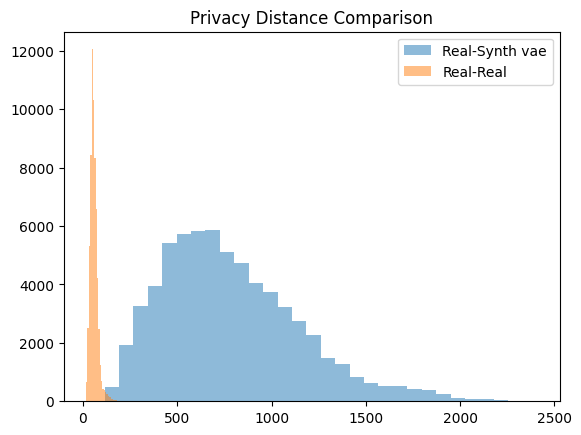

Avg nearest neighbor distance vae: 785.579 ± 365.448
✅ Synthetic samples are sufficiently distinct


In [21]:
from sklearn.metrics.pairwise import euclidean_distances
import numpy as np

Evaluation_results ["Privacy"]["NN Similarity test"] = {"Criterions" : ["AvgNN", "StdNN"]}

diff = 0.3

def nearest_neighbor_distance(X, Y=None):
    if Y is None:
        Y = X
        same_set = True
    else:
        same_set = False

    D = euclidean_distances(X, Y)
    
    # If comparing the same set, ignore self-distances
    if same_set:
        np.fill_diagonal(D, np.inf)
    
    nearest_dist = D.min(axis=1)
    return nearest_dist.mean(), nearest_dist.std(), nearest_dist

rr_mean, rr_std, rr_nearest = nearest_neighbor_distance(X_train, None) 
Evaluation_results ["Privacy"]["NN Similarity test"]["Self"] = [rr_mean, rr_std]
print(f"Avg nearest neighbor distance RR: {rr_mean:.3f} ± {rr_std:.3f}")


for model, data in generated_data.items(): 
    mean_d, std_d, nearest_d = nearest_neighbor_distance(X_train, data)
    Evaluation_results ["Privacy"]["NN Similarity test"][model] = [mean_d, std_d]
    plt.hist(nearest_d, bins=30, alpha=0.5, label=f'Real-Synth {model}')
    plt.hist(rr_nearest, bins=30, alpha=0.5, label='Real-Real')
    plt.legend(); plt.title("Privacy Distance Comparison")
    plt.show()
    print(f"Avg nearest neighbor distance {model}: {mean_d:.3f} ± {std_d:.3f}")
    if mean_d - rr_mean / rr_mean < -diff:
        print("⚠️ Potential overfitting / privacy leak")
    else:
        print("✅ Synthetic samples are sufficiently distinct")


Membership Inference 

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier

Evaluation_results ["Privacy"]["Membership Inference"] = {"Criterions" : ["ACC"]}

for model, data in generated_data.items(): 

    # Label real data (1) and synthetic (0)
    X = np.concatenate([X_train, data])
    y = np.concatenate([np.ones(len(X_train)), np.zeros(len(data))])

    X_train_, X_test_, y_train_, y_test_ = train_test_split(X, y, test_size=0.3, stratify=y)
    clf = RandomForestClassifier().fit(X_train_, y_train_)
    acc = clf.score(X_test_, y_test_)
    Evaluation_results ["Privacy"]["Membership Inference"][model] = acc
    print(f"Membership inference accuracy {model}: {acc:.2f}")


Membership inference accuracy ddpm: 0.93
Membership inference accuracy gan: 0.99
Membership inference accuracy nf: 0.93
Membership inference accuracy vae: 1.00


# Utility

In [23]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    mean_absolute_error, 
    mean_squared_error,
    r2_score,
    ConfusionMatrixDisplay
)

In [24]:

def regression_report(y_true_sequences, y_pred_sequences): # Added plot_ceg flag
    """
    Generates a comprehensive regression report.

    Parameters:
    - y_true_sequences (array-like): True target values. Can be 1D or 2D (n_samples x PH).
    - y_pred_sequences (array-like): Predicted target values. Shape must match.

    Returns:
    - report (List): List containing regression metrics.
    - (optional) all_delays_for_sequences (list): List of individual delays if return_individual_delays is True.
    """
    y_true = np.asarray(y_true_sequences)
    y_pred = np.asarray(y_pred_sequences)

    if y_true.shape != y_pred.shape:
        IndexError("RegressionReport: y_true and y_pred shapes mismatch. Cannot proceed.")
        return {"Error": "Shape mismatch between y_true and y_pred."}

    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred.flatten()

    # --- Standard Regression Metrics (MAE, MSE, RMSE, R2, MAPE) ---
    # ... (same as your existing code for these metrics) ...
    mae = mean_absolute_error(y_true_flat, y_pred_flat)
    mse = mean_squared_error(y_true_flat, y_pred_flat)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true_flat, y_pred_flat)
    mask = y_true_flat != 0
    mape = np.mean(np.abs((y_true_flat[mask] - y_pred_flat[mask]) / y_true_flat[mask])) * 100 if np.any(mask) else np.nan
    
    return [mae, mse, rmse, mape, r2]

In [25]:
PH = 8

X_train_in = X_train[:, :-PH]
X_val_in = X_val[:, :-PH]
X_test_in = X_test[:, :-PH]  

y_train_in_reg = X_train[:, -PH:]
y_val_in_reg = X_val[:, -PH:]
y_test_in_reg = X_test[:, -PH:] 

Regression

In [26]:
Evaluation_results ["Utility"] = {}
Evaluation_results ["Utility"]["Regression"] = {"Criterions" : ["MAE", "MSE", "RMSE", "MAPE", "R2Score"]}

for model, data in generated_data.items(): 

    X_train_synth = data[:, :-PH]  

    y_train_synth = data[:, -PH:]

    clf = RandomForestRegressor(n_jobs= 8).fit(X_train_synth, y_train_synth)
    y_synth_pred = clf.predict(X_train_in)
    report = regression_report(y_train_in_reg, y_synth_pred)
    Evaluation_results ["Utility"]["Regression"][model] = report
    print(f"Regression RMSE {model}: {report[2]:.2f}")


Regression RMSE ddpm: 17.15
Regression RMSE gan: 20.31
Regression RMSE nf: 17.18
Regression RMSE vae: 90.54


In [27]:
Evaluation_results ["Utility"] = {}
Evaluation_results ["Utility"]["Regression_val"] = {"Criterions" : ["MAE", "MSE", "RMSE", "MAPE", "R2Score"]}

clf = RandomForestRegressor(n_jobs= 6).fit(X_train_in, y_train_in_reg)
y_pred = clf.predict(X_val_in)
report = regression_report(y_val_in_reg, y_pred)
Evaluation_results ["Utility"]["Regression_val"]["real"] = report
print(f"Regression RMSE real: {report[2]:.2f}")

for model, data in generated_data.items(): 

    X_synth = data[:, :-PH]  

    y_synth = data[:, -PH:]

    clf = RandomForestRegressor(n_jobs= 6).fit(X_synth, y_synth)
    y_synth_pred = clf.predict(X_test_in)
    report = regression_report(y_test_in_reg, y_synth_pred)
    Evaluation_results ["Utility"]["Regression_val"][model] = report
    print(f"Regression RMSE {model}: {report[2]:.2f}")

Regression RMSE real: 16.90
Regression RMSE ddpm: 18.70
Regression RMSE gan: 21.67
Regression RMSE nf: 18.45
Regression RMSE vae: 94.14


classification

In [28]:
def class_targets(y_reg, classes:list=[180,60], index:int=None): 

    num_classes = len(classes) + 1
    y_clf = np.ones_like(y_reg) * int(num_classes)
    for num_class, limit in enumerate(classes):
        y_clf = np.where(y_reg < limit, int(num_classes - 1 - num_class), y_clf)

    if index is None: 
        y_clf = y_clf.min(axis = 1) 
    elif isinstance(index, list):
        y_clf = y_clf[:, index].min(axis = 1) 
    else:
        assert index < y_reg.shape[1]
        y_clf = y_clf[:, index]
    y_clf = y_clf - 1
    
    return y_clf

In [29]:
Evaluation_results ["Utility"] = {}
Evaluation_results ["Utility"]["Classification_val"] = {"Criterions" : ["Confusion MAtrix"]}

y_train_clf_in = class_targets(y_train_in_reg) 
y_val_clf_in = class_targets(y_val_in_reg) 
y_test_clf_in = class_targets(y_test_in_reg) 

clf = RandomForestClassifier(n_jobs= 8).fit(X_train_in, y_train_clf_in)
y_pred = clf.predict(X_val_in)
report = classification_report(y_val_clf_in, y_pred)
Evaluation_results ["Utility"]["Classification_val"]["real"] = report
print(f"Regression clf_report real: ")
print(report)


for model, data in generated_data.items(): 

    X_synth = data[:, :-PH]  

    y_synth = data[:, -PH:]
    
    y_clf = class_targets(y_synth)

    clf = RandomForestClassifier(n_jobs= 8).fit(X_synth, y_clf, )
    y_synth_pred = clf.predict(X_test_in)
    report = classification_report(y_test_clf_in, y_synth_pred)
    Evaluation_results ["Utility"]["Classification_val"][model] = report
    print(f"Regression clf_report {model}: ")
    print(report)

Regression clf_report real: 
              precision    recall  f1-score   support

         0.0       0.84      0.32      0.47       428
         1.0       0.94      0.93      0.94     18545
         2.0       0.87      0.92      0.89      8895

    accuracy                           0.92     27868
   macro avg       0.88      0.72      0.77     27868
weighted avg       0.92      0.92      0.92     27868

Regression clf_report ddpm: 
              precision    recall  f1-score   support

         0.0       0.79      0.47      0.59       254
         1.0       0.95      0.95      0.95      7389
         2.0       0.87      0.91      0.89      2686

    accuracy                           0.93     10329
   macro avg       0.87      0.78      0.81     10329
weighted avg       0.93      0.93      0.92     10329

Regression clf_report gan: 
              precision    recall  f1-score   support

         0.0       0.73      0.03      0.06       254
         1.0       0.92      0.95      0.94

c:\Users\MEROUANE\miniconda3\envs\data\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\MEROUANE\miniconda3\envs\data\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\MEROUANE\miniconda3\envs\data\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result)